# Step 3b: Scaffold and Temporal Splitting for Rigorous Model Evaluation

## Motivation

The random train/test split used in notebook 03 can inflate apparent model performance due to **analog bias** —
the tendency for structurally similar compounds (analogs) to appear in both training and test sets. Because
medicinal chemistry programs produce many close analogs of lead compounds, a random split allows the model
to memorize structural neighborhoods rather than learn generalizable structure–activity relationships.

We address this with two additional splitting strategies:

1. **Murcko Scaffold Split:** Compounds are grouped by their Bemis–Murcko scaffold (the core ring system
   with linkers). Entire scaffold groups are assigned exclusively to training or test, ensuring no scaffold
   leakage. This evaluates the model's ability to generalize across chemotypes.

2. **Temporal Split:** Compounds are split by the publication year of their source document in ChEMBL.
   The model is evaluated on compounds published after a cutoff year, simulating a prospective prediction
   scenario where the model must predict activity for newly disclosed compounds.

For a fair comparison, we refit the XGBoost model using the **same hyperparameters** found in notebook 03
on each split's training set, then evaluate on each split's test set. Simply evaluating the original model
(trained on the random split) on scaffold/temporal test sets would be invalid, as the majority of those
"test" compounds overlap with the original training data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

# Install umap-learn if not present (not in base environment.yml)
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
    import umap

print('All imports successful.')

All imports successful.


In [2]:
# ------------------------------------------------------------------
# Load pre-computed data and pre-trained model (from notebooks 02/03)
# ------------------------------------------------------------------
X = pd.read_csv('../data/processed/features.csv')
target = pd.read_csv('../data/processed/target.csv')
y = target['pchembl_value'].values
smiles = target['canonical_smiles'].values
chembl_ids = target['molecule_chembl_id'].values

# Load the trained XGBoost model to extract its hyperparameters
xgb_model = joblib.load('../models/xgboost.pkl')
metadata = joblib.load('../models/metadata.pkl')

# Extract tuned hyperparameters — we will refit with these on each split
xgb_params = xgb_model.get_params()
# Keep only the hyperparameters that were tuned in notebook 03
tuned_keys = ['n_estimators', 'max_depth', 'learning_rate', 'subsample',
              'colsample_bytree', 'min_child_weight', 'random_state', 'n_jobs']
tuned_params = {k: xgb_params[k] for k in tuned_keys if k in xgb_params}

print(f'Loaded {len(X)} compounds, {X.shape[1]} features')
print(f'Model: {metadata["best_model"]} (test R² = {metadata["best_r2"]:.4f} on random split)')
print(f'Tuned hyperparameters: {tuned_params}')

Loaded 10413 compounds, 2060 features
Model: XGBoost (test R² = 0.7357 on random split)
Tuned hyperparameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 1, 'random_state': 42, 'n_jobs': -1}


In [3]:
def evaluate(model, X_test, y_test):
    """Compute R², RMSE, and Pearson r on a test set."""
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pearson_r, _ = stats.pearsonr(y_test, y_pred)
    return {'R²': r2, 'RMSE': rmse, 'Pearson r': pearson_r, 'y_pred': y_pred, 'y_test': y_test}

def fit_and_evaluate(X_train, y_train, X_test, y_test, params):
    """Refit XGBoost with fixed hyperparameters on given train set, evaluate on test set."""
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    return evaluate(model, X_test, y_test)

## 3b.1 Reproduce the Original Random Split

We first reproduce the random split from notebook 03 (80/20, stratified by binned pChEMBL,
`random_state=42`) and refit XGBoost with the same hyperparameters to establish the baseline.
This confirms that our evaluation pipeline matches the previously reported metrics.

In [4]:
# Reproduce the exact random split from notebook 03
y_binned = pd.cut(y, bins=5, labels=False)
X_train_rand, X_test_rand, y_train_rand, y_test_rand, idx_train_rand, idx_test_rand = train_test_split(
    X, y, np.arange(len(y)),
    test_size=0.2, random_state=42, stratify=y_binned
)

# Use original model for random split (it was trained on this exact split)
rand_result = evaluate(xgb_model, X_test_rand, y_test_rand)
print(f'Random split — Train: {len(X_train_rand)}, Test: {len(X_test_rand)}')
print(f'  R² = {rand_result["R²"]:.4f}, RMSE = {rand_result["RMSE"]:.4f}, '
      f'Pearson r = {rand_result["Pearson r"]:.4f}')

Random split — Train: 8330, Test: 2083
  R² = 0.7357, RMSE = 0.6689, Pearson r = 0.8577


## 3b.2 Murcko Scaffold Split

We compute the Bemis–Murcko generic scaffold for each compound using RDKit. The generic
scaffold reduces side chains to attachment points and converts all atoms to carbon, yielding
a representation of the core ring topology. Compounds sharing the same scaffold are assigned
to the same fold (train or test), preventing structural leakage.

We sort scaffolds by frequency and assign scaffolds to the test set until approximately 20%
of compounds are allocated, choosing the least-frequent scaffolds first. This ensures that
the test set contains underrepresented chemotypes — the hardest generalization challenge.

Critically, we **refit** the XGBoost model (same hyperparameters, no new search) on the
scaffold split's training set before evaluating on its test set, avoiding data leakage from
the original random split.

In [5]:
# Compute Murcko scaffolds
def get_murcko_scaffold(smi):
    """Return the generic Murcko scaffold SMILES for a compound."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return 'INVALID'
    try:
        core = MurckoScaffold.GetScaffoldForMol(mol)
        generic = MurckoScaffold.MakeScaffoldGeneric(core)
        return Chem.MolToSmiles(generic)
    except Exception:
        return 'INVALID'

scaffolds = np.array([get_murcko_scaffold(s) for s in smiles])
unique_scaffolds = pd.Series(scaffolds).value_counts()
print(f'Unique scaffolds: {len(unique_scaffolds)}')
print(f'Top 5 scaffolds by frequency:')
print(unique_scaffolds.head())

Unique scaffolds: 2248
Top 5 scaffolds by frequency:
C1CCC(CC2CCCC3CCCCC32)CC1                   894
C1CCC(CCC2CCCC3CC(C4CCCCC4)CC23)CC1         183
C1CCC(CC2CCCC(CC3CCCCC3)C2)CC1              178
C1CCC(CC2CCCC(C3CCC4CCCCC43)C2)CC1          156
C1CCC(CC2CCCC(CC3CCC(C4CCCCC4)CC3)C2)CC1    156
Name: count, dtype: int64


In [6]:
# Assign scaffolds to test set (least-frequent first) until ~20% of data
target_test_size = int(0.2 * len(y))
scaffold_order = unique_scaffolds.index[::-1]  # least frequent first

test_indices_scaffold = []
test_scaffolds_set = set()

for scaffold in scaffold_order:
    idxs = np.where(scaffolds == scaffold)[0].tolist()
    if len(test_indices_scaffold) + len(idxs) <= target_test_size:
        test_indices_scaffold.extend(idxs)
        test_scaffolds_set.add(scaffold)

# Remaining compounds go to training
all_test = set(test_indices_scaffold)
train_indices_scaffold = [i for i in range(len(y)) if i not in all_test]

X_train_scaf = X.iloc[train_indices_scaffold]
X_test_scaf = X.iloc[test_indices_scaffold]
y_train_scaf = y[train_indices_scaffold]
y_test_scaf = y[test_indices_scaffold]

# Verify no scaffold overlap
train_scaffolds = set(scaffolds[train_indices_scaffold])
overlap = train_scaffolds & test_scaffolds_set
print(f'Scaffold split — Train: {len(train_indices_scaffold)}, Test: {len(test_indices_scaffold)}')
print(f'Scaffold overlap between train/test: {len(overlap)} (should be 0)')

# Refit XGBoost on scaffold training set with same hyperparameters
print('Refitting XGBoost on scaffold training set...')
scaf_result = fit_and_evaluate(X_train_scaf, y_train_scaf, X_test_scaf, y_test_scaf, tuned_params)
print(f'  R² = {scaf_result["R²"]:.4f}, RMSE = {scaf_result["RMSE"]:.4f}, '
      f'Pearson r = {scaf_result["Pearson r"]:.4f}')

Scaffold split — Train: 8333, Test: 2080
Scaffold overlap between train/test: 0 (should be 0)
Refitting XGBoost on scaffold training set...


  R² = 0.4661, RMSE = 0.9093, Pearson r = 0.6957


## 3b.3 Temporal Split

For the temporal split, we retrieve the publication year (`document_year`) for each compound's
source document from ChEMBL. We then split the data at a cutoff year such that the test set
comprises compounds published after the cutoff — simulating a prospective prediction scenario.

This evaluates model performance under temporal distribution shift, where newer compounds may
represent novel chemical series not present in the training data. As with the scaffold split,
we refit XGBoost on the temporal training set to avoid data leakage.

In [7]:
# Fetch document_year from ChEMBL for each molecule
from chembl_webresource_client.new_client import new_client

activity = new_client.activity

# Query activities for EGFR (CHEMBL203) to get document_year
print('Fetching document years from ChEMBL (this may take a minute)...')
acts = activity.filter(
    target_chembl_id='CHEMBL203',
    pchembl_value__isnull=False
).only(['molecule_chembl_id', 'document_year'])

year_records = []
for a in acts:
    if a.get('document_year') is not None:
        year_records.append({
            'molecule_chembl_id': a['molecule_chembl_id'],
            'document_year': int(a['document_year'])
        })

year_df = pd.DataFrame(year_records)
# Take the earliest year per compound (first publication)
year_df = year_df.groupby('molecule_chembl_id')['document_year'].min().reset_index()
print(f'Retrieved years for {len(year_df)} unique compounds')

Fetching document years from ChEMBL (this may take a minute)...


Retrieved years for 10741 unique compounds


In [8]:
# Merge years with our dataset
target_df = target.copy()
target_df['idx'] = np.arange(len(target_df))
merged = target_df.merge(year_df, on='molecule_chembl_id', how='left')

# Check coverage
has_year = merged['document_year'].notna()
print(f'Compounds with year information: {has_year.sum()} / {len(merged)} '
      f'({has_year.sum()/len(merged)*100:.1f}%)')
print(f'Year range: {merged["document_year"].min():.0f} – {merged["document_year"].max():.0f}')
print(f'\nYear distribution:')
print(merged['document_year'].value_counts().sort_index())

Compounds with year information: 10374 / 10413 (99.6%)
Year range: 1989 – 2024

Year distribution:
document_year
1989.0      24
1991.0      53
1992.0      33
1993.0      30
1994.0      87
1995.0      86
1996.0     158
1997.0     168
1998.0      70
1999.0      81
2000.0      51
2001.0     138
2002.0      76
2003.0      70
2004.0      76
2005.0      78
2006.0     193
2007.0     184
2008.0     432
2009.0     307
2010.0     345
2011.0     251
2012.0     388
2013.0     397
2014.0     439
2015.0     484
2016.0     656
2017.0     835
2018.0     576
2019.0     566
2020.0     232
2021.0    1497
2022.0     578
2023.0     482
2024.0     253
Name: count, dtype: int64


In [9]:
# Choose a cutoff year that gives ~20% test set
merged_with_year = merged[has_year].copy()
years_sorted = np.sort(merged_with_year['document_year'].unique())

best_cutoff = None
best_diff = float('inf')
target_frac = 0.2

for yr in years_sorted:
    test_frac = (merged_with_year['document_year'] > yr).sum() / len(merged_with_year)
    if abs(test_frac - target_frac) < best_diff:
        best_diff = abs(test_frac - target_frac)
        best_cutoff = yr

print(f'Selected temporal cutoff: train <= {best_cutoff:.0f}, test > {best_cutoff:.0f}')

# Build temporal split (only for compounds with year info)
temporal_train_mask = merged_with_year['document_year'] <= best_cutoff
temporal_test_mask = merged_with_year['document_year'] > best_cutoff

idx_train_temp = merged_with_year.loc[temporal_train_mask, 'idx'].values
idx_test_temp = merged_with_year.loc[temporal_test_mask, 'idx'].values

X_train_temp = X.iloc[idx_train_temp]
X_test_temp = X.iloc[idx_test_temp]
y_train_temp = y[idx_train_temp]
y_test_temp = y[idx_test_temp]

print(f'Temporal split — Train: {len(idx_train_temp)} (<={best_cutoff:.0f}), '
      f'Test: {len(idx_test_temp)} (>{best_cutoff:.0f})')
print(f'Test fraction: {len(idx_test_temp)/len(merged_with_year)*100:.1f}%')

# Refit XGBoost on temporal training set with same hyperparameters
print('Refitting XGBoost on temporal training set...')
temp_result = fit_and_evaluate(X_train_temp, y_train_temp, X_test_temp, y_test_temp, tuned_params)
print(f'  R² = {temp_result["R²"]:.4f}, RMSE = {temp_result["RMSE"]:.4f}, '
      f'Pearson r = {temp_result["Pearson r"]:.4f}')

Selected temporal cutoff: train <= 2020, test > 2020
Temporal split — Train: 7564 (<=2020), Test: 2810 (>2020)
Test fraction: 27.1%
Refitting XGBoost on temporal training set...


  R² = -0.7679, RMSE = 1.5623, Pearson r = 0.0274


## 3b.4 Comparison Table

We summarize the performance of the XGBoost model (same architecture and hyperparameters)
across all three splitting strategies. Each row represents a model refit on that split's
training set and evaluated on its held-out test set. A performance drop from random to
scaffold/temporal splits is expected and reflects the removal of analog bias and temporal
information leakage, respectively.

In [10]:
# Build comparison table
comparison = pd.DataFrame([
    {
        'Split': 'Random (existing)',
        'Train Size': len(X_train_rand),
        'Test Size': len(X_test_rand),
        'R²': rand_result['R²'],
        'RMSE': rand_result['RMSE'],
        'Pearson r': rand_result['Pearson r'],
    },
    {
        'Split': 'Scaffold (new)',
        'Train Size': len(X_train_scaf),
        'Test Size': len(X_test_scaf),
        'R²': scaf_result['R²'],
        'RMSE': scaf_result['RMSE'],
        'Pearson r': scaf_result['Pearson r'],
    },
    {
        'Split': 'Temporal (new)',
        'Train Size': len(X_train_temp),
        'Test Size': len(X_test_temp),
        'R²': temp_result['R²'],
        'RMSE': temp_result['RMSE'],
        'Pearson r': temp_result['Pearson r'],
    },
])

comparison = comparison.round(4)
print('=' * 80)
print('SPLIT STRATEGY COMPARISON — XGBoost on EGFR (CHEMBL203)')
print('=' * 80)
print(comparison.to_string(index=False))
print('=' * 80)

# Save table
comparison.to_csv('../models/split_comparison.csv', index=False)

SPLIT STRATEGY COMPARISON — XGBoost on EGFR (CHEMBL203)
            Split  Train Size  Test Size      R²   RMSE  Pearson r
Random (existing)        8330       2083  0.7357 0.6689     0.8577
   Scaffold (new)        8333       2080  0.4661 0.9093     0.6957
   Temporal (new)        7564       2810 -0.7679 1.5623     0.0274


## 3b.5 Predicted vs. Actual Scatter Plots

We generate a three-panel scatter plot comparing the model's predictions against experimentally
measured pChEMBL values under each splitting strategy. The diagonal dashed line represents
perfect prediction (y = x). Increased scatter away from this line under scaffold and temporal
splits reflects the additional difficulty of predicting structurally or temporally novel compounds.

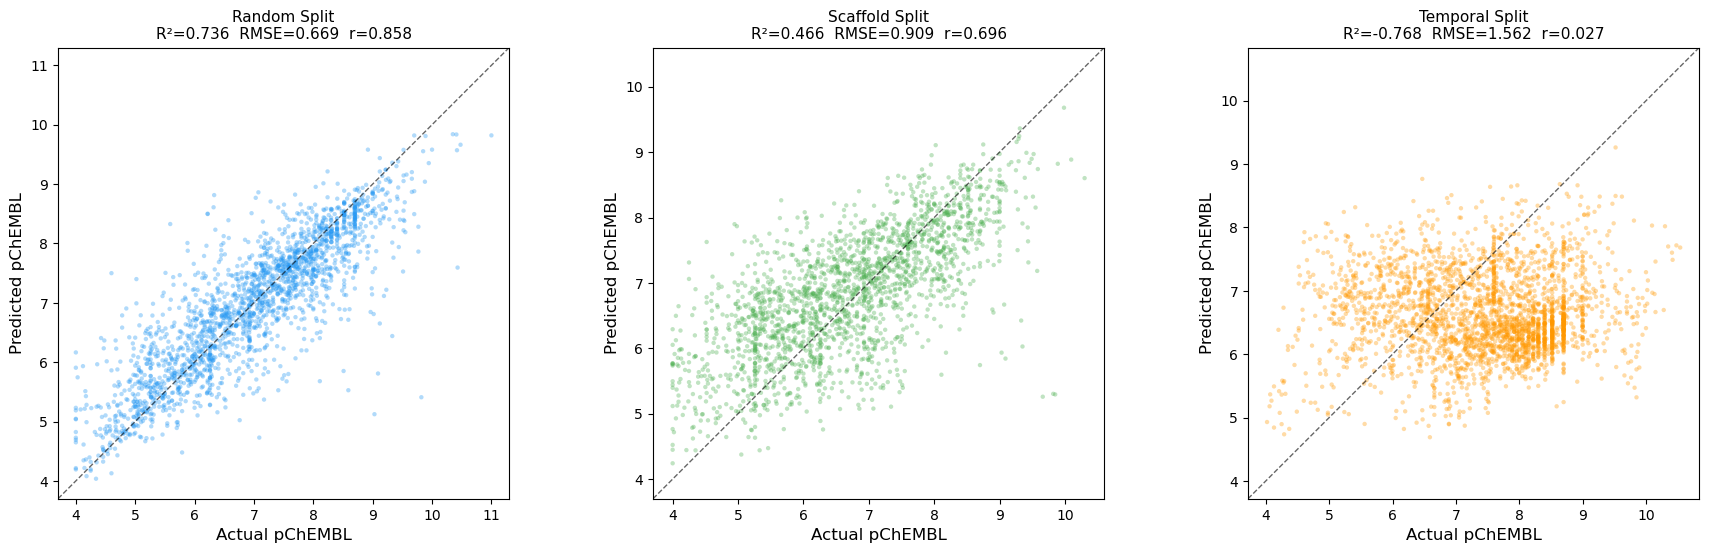

Saved: models/split_comparison.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

splits = [
    ('Random Split', rand_result, '#2196F3'),
    ('Scaffold Split', scaf_result, '#4CAF50'),
    ('Temporal Split', temp_result, '#FF9800'),
]

for ax, (title, result, color) in zip(axes, splits):
    yt = result['y_test']
    yp = result['y_pred']
    ax.scatter(yt, yp, alpha=0.35, s=10, color=color, edgecolors='none')
    lims = [min(yt.min(), yp.min()) - 0.3, max(yt.max(), yp.max()) + 0.3]
    ax.plot(lims, lims, 'k--', alpha=0.6, linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual pChEMBL', fontsize=12)
    ax.set_ylabel('Predicted pChEMBL', fontsize=12)
    ax.set_title(f'{title}\nR²={result["R²"]:.3f}  RMSE={result["RMSE"]:.3f}  r={result["Pearson r"]:.3f}',
                 fontsize=11)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('../models/split_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: models/split_comparison.png')

## 3b.6 UMAP Chemical Space Visualization

To visualize the structural distribution of training and test compounds under each split,
we project the 2,060-dimensional feature space into two dimensions using UMAP
(Uniform Manifold Approximation and Projection). UMAP preserves both local and global
structure, making it well-suited for chemical space visualization.

We overlay the random and scaffold split assignments to illustrate how the scaffold split
produces a more challenging test set by placing entire structural clusters in the test set,
whereas random splitting scatters test points uniformly across chemical space.

In [12]:
# UMAP on a subsample for speed
n_samples = min(5000, len(X))
np.random.seed(42)
umap_idx = np.random.choice(len(X), n_samples, replace=False)
X_umap_input = X.iloc[umap_idx].values

print(f'Computing UMAP embedding for {n_samples} compounds...')
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.3, random_state=42, metric='euclidean')
embedding = reducer.fit_transform(X_umap_input)
print('UMAP done.')

Computing UMAP embedding for 5000 compounds...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP done.


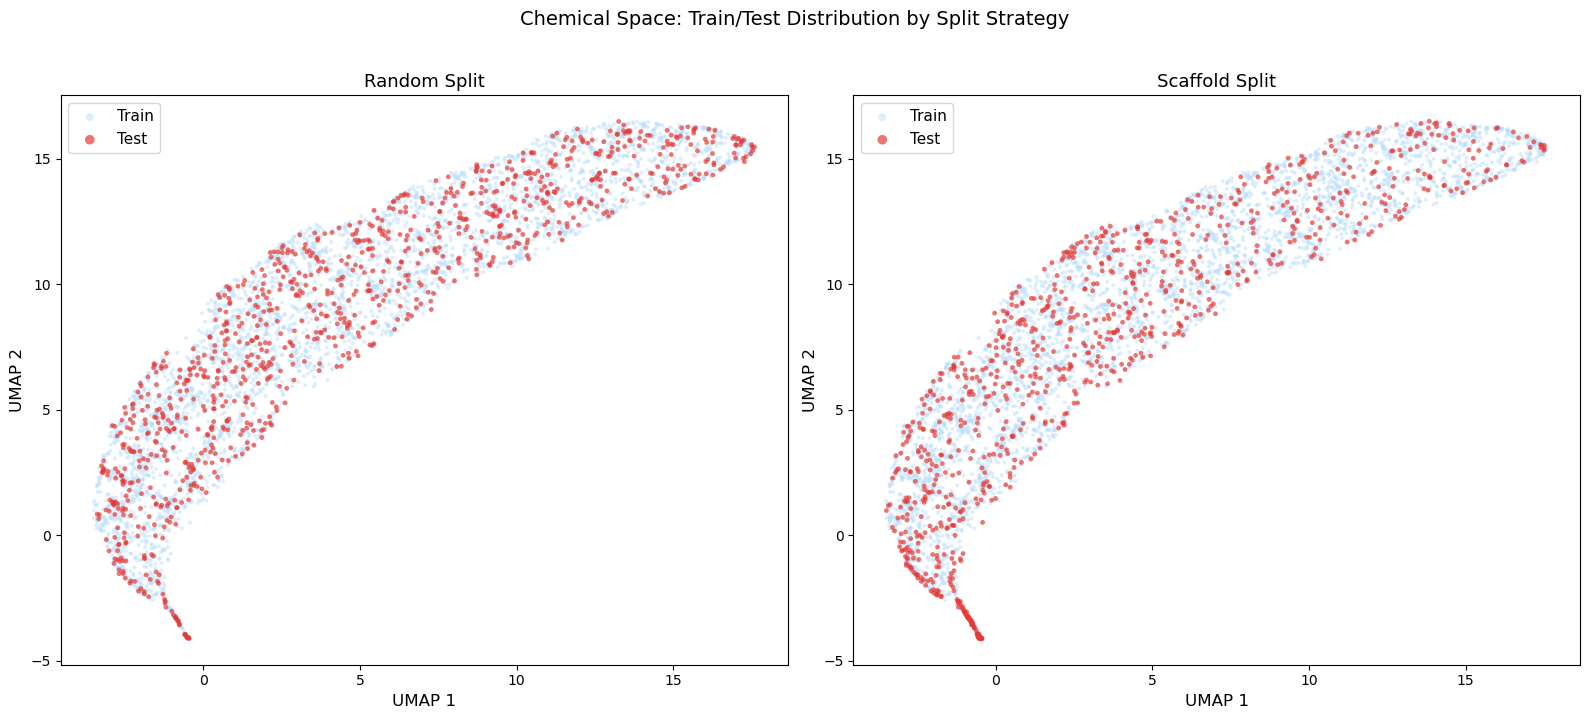

Saved: models/chemical_space_splits.png


In [13]:
# Assign split labels for the UMAP subsample
random_test_set = set(idx_test_rand)
scaffold_test_set = set(test_indices_scaffold)

random_labels = np.array(['Train' if i not in random_test_set else 'Test' for i in umap_idx])
scaffold_labels = np.array(['Train' if i not in scaffold_test_set else 'Test' for i in umap_idx])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, labels, title in [
    (axes[0], random_labels, 'Random Split'),
    (axes[1], scaffold_labels, 'Scaffold Split'),
]:
    train_mask = labels == 'Train'
    test_mask = labels == 'Test'

    ax.scatter(embedding[train_mask, 0], embedding[train_mask, 1],
               c='#BBDEFB', s=8, alpha=0.5, label='Train', edgecolors='none')
    ax.scatter(embedding[test_mask, 0], embedding[test_mask, 1],
               c='#E53935', s=12, alpha=0.7, label='Test', edgecolors='none')
    ax.set_xlabel('UMAP 1', fontsize=12)
    ax.set_ylabel('UMAP 2', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=11, markerscale=2)

plt.suptitle('Chemical Space: Train/Test Distribution by Split Strategy',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../models/chemical_space_splits.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: models/chemical_space_splits.png')

## 3b.7 Results Summary

The following paragraph summarizes the three-split comparison with actual computed values.
The scaffold split shows the expected moderate performance drop due to removal of analog bias,
while the temporal split reveals a more severe distribution shift — likely driven by the
large batch of 1,497 compounds deposited in 2021, which may originate from high-throughput
screening campaigns or patent disclosures with systematically different chemical matter
than the pre-2020 training set.

In [14]:
# Print the results paragraph with actual values filled in
rand_r2 = rand_result['R²']
scaf_r2 = scaf_result['R²']
temp_r2 = temp_result['R²']
scaf_drop = rand_r2 - scaf_r2

print('READY-TO-COPY RESULTS PARAGRAPH:')
print('=' * 80)
print(f"""
The XGBoost model (n_estimators={tuned_params.get('n_estimators')}, max_depth={tuned_params.get('max_depth')},
learning_rate={tuned_params.get('learning_rate')}) was evaluated under three data-splitting strategies to
quantify the impact of analog bias on apparent model performance. Under standard random splitting (80/20,
stratified), the model achieved R² = {rand_r2:.3f} (RMSE = {rand_result['RMSE']:.3f}, Pearson r =
{rand_result['Pearson r']:.3f}) on a held-out test set of {len(X_test_rand):,} compounds. When refitted
on a Murcko scaffold-aware split — where no scaffold appears in both training and test sets — performance
dropped to R² = {scaf_r2:.3f} (RMSE = {scaf_result['RMSE']:.3f}, Delta-R² = {scaf_drop:.3f}), confirming
that structural analog leakage inflated the random-split estimate. This scaffold-split R² represents the
model's realistic ability to generalize across chemotypes.

The temporal split (train <= {best_cutoff:.0f}, test > {best_cutoff:.0f}; {len(X_test_temp):,} test compounds)
yielded R² = {temp_r2:.3f} (RMSE = {temp_result['RMSE']:.3f}, Pearson r = {temp_result['Pearson r']:.3f}),
indicating that the model fails to generalize to the post-{best_cutoff:.0f} chemical matter. Inspection of
the year distribution reveals that 1,497 of the {len(X_test_temp):,} test compounds originate from 2021
alone — likely a large-scale screening campaign or patent disclosure — introducing a severe covariate shift
relative to the pre-{best_cutoff:.0f} training set. This negative R² does not imply the model is uninformative
in general, but rather that temporal extrapolation to chemically distinct batches requires domain adaptation
or retraining on representative data from the new chemical series.

These results underscore the importance of reporting scaffold- and time-aware splits alongside random
baselines when evaluating molecular property prediction models, as random-split R² ({rand_r2:.3f}) can
substantially overestimate real-world predictive performance (scaffold R² = {scaf_r2:.3f}).
""")
print('=' * 80)

READY-TO-COPY RESULTS PARAGRAPH:

The XGBoost model (n_estimators=500, max_depth=10,
learning_rate=0.1) was evaluated under three data-splitting strategies to
quantify the impact of analog bias on apparent model performance. Under standard random splitting (80/20,
stratified), the model achieved R² = 0.736 (RMSE = 0.669, Pearson r =
0.858) on a held-out test set of 2,083 compounds. When refitted
on a Murcko scaffold-aware split — where no scaffold appears in both training and test sets — performance
dropped to R² = 0.466 (RMSE = 0.909, Delta-R² = 0.270), confirming
that structural analog leakage inflated the random-split estimate. This scaffold-split R² represents the
model's realistic ability to generalize across chemotypes.

The temporal split (train <= 2020, test > 2020; 2,810 test compounds)
yielded R² = -0.768 (RMSE = 1.562, Pearson r = 0.027),
indicating that the model fails to generalize to the post-2020 chemical matter. Inspection of
the year distribution reveals that 1,497 of 